In [1]:
import numpy as np

# Sigmoid function:
def numpy_sigmoid(x):
    return 1/(1+np.exp(-x))

# Derivative of sigmoid function:
def der_sigmoid(x):
    return numpy_sigmoid(x)*(1-numpy_sigmoid(x))

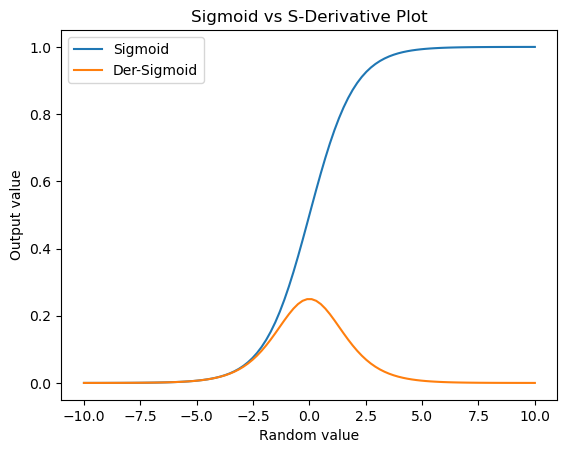

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rdata = np.linspace(-10, 10, 100)
output = numpy_sigmoid(rdata)
doutput = der_sigmoid(rdata)

plt.plot(rdata, output, label = "Sigmoid")
plt.plot(rdata, doutput, label = "Der-Sigmoid")
plt.xlabel("Random value")
plt.ylabel("Output value")
plt.title("Sigmoid vs S-Derivative Plot")
plt.legend()

In [5]:
def numpy_relu(x):
    return np.maximum(x, 0)

def rel_der(x):
    x[x<=0] = 0
    x[x>0] = 1
    return x

def rel_der1(x):
    return np.heaviside(x, 0)


Text(0.5, 1.0, 'Relu Plot')

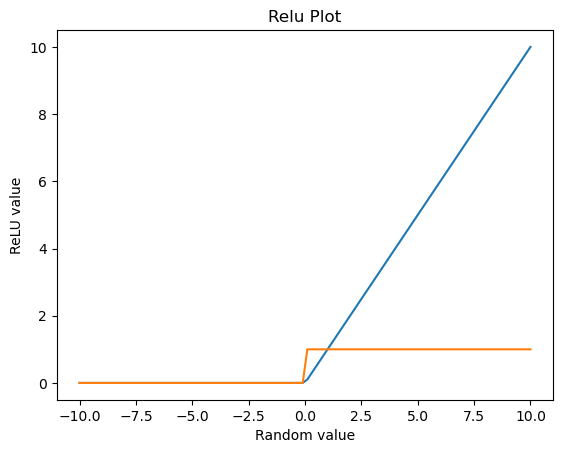

In [7]:
rdata = np.linspace(-10, 10, 100)
#print(rdata)
rl_out = numpy_relu(rdata)
rl_dev_out = rel_der1(rdata)
#print(rl_out)
plt.plot(rdata, rl_out)
plt.plot(rdata, rl_dev_out)
plt.xlabel("Random value")
plt.ylabel("ReLU value")
plt.title("Relu Plot")


In [9]:

def numpy_softmax(x):   
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()


def sm_der(S):
    nv = S.reshape(-1,1)
    sij = np.dot(nv, nv.T)
    s_dir = np.diag(S) - sij
    return s_dir


Text(0.5, 1.0, 'SM vs SM-Derivative Plot')

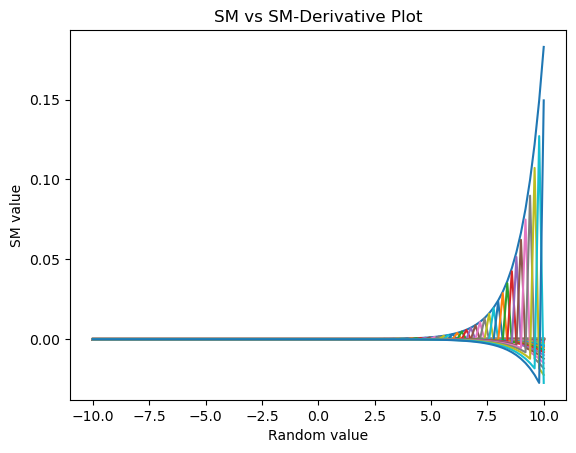

In [11]:
rdata = np.linspace(-10, 10, 100)

sm = numpy_softmax(rdata)
s_der = sm_der(sm)

plt.plot(rdata, sm)
plt.plot(rdata, s_der)
plt.xlabel("Random value")
plt.ylabel("SM value")
plt.title("SM vs SM-Derivative Plot")

In [13]:
import numpy as np

In [15]:
def relu(input):
    '''Define your relu activation function here'''
    # Calculate the value for the output of the relu function: output
    output = max(0, input)
    # Return the value just calculated
    return(output)

In [17]:
def predict_with_network(input_data, weights):
    # Calculate node 0 in the first hidden layer
   
    node_0_0_input = (input_data * weights[0]).sum()
    node_0_0_output = relu(node_0_0_input)

    # Calculate node 1 in the first hidden layer
    node_0_1_input = (input_data* weights[1]).sum()
    node_0_1_output = relu(node_0_1_input)

    # Put node values into array: hidden_0_outputs
    hidden_0_outputs = np.array([node_0_0_output, node_0_1_output])
    print("Hidden Layer 1 Output:", hidden_0_outputs)      
    
    # Calculate model output: model_output
    model_output = (hidden_0_outputs * weights[2]).sum()
    # Return model_output
    return(model_output)

input_data = np.array([3,5])
w_data = [[2,4], [4,-5],[2,7]]

output = predict_with_network(input_data, w_data)
print("Model's Prediction:", output)

Hidden Layer 1 Output: [26  0]
Model's Prediction: 52


In [19]:
def predict_with_network1(input_data, weights):
    # Calculate node 0 in the first hidden layer   
    node_0_0_input = (input_data * weights[0]).sum()
    node_0_0_output = relu(node_0_0_input)

    # Calculate node 1 in the first hidden layer
    node_0_1_input = (input_data * weights[1]).sum()
    node_0_1_output = relu(node_0_1_input)

    # Put node values into array: hidden_0_outputs
    hidden_0_outputs = np.array([node_0_0_output, node_0_1_output])
    print("Hidden Layer 1 Output:", hidden_0_outputs)    
   
    # Calculate node 0 in the second hidden layer
    node_1_0_input =  (hidden_0_outputs * weights[2]).sum()    
    node_1_0_output = relu(node_1_0_input)
   
    # Calculate node 1 in the second hidden layer    
    node_1_1_input = (hidden_0_outputs * weights[3]).sum() 
    node_1_1_output = relu(node_1_1_input)

    # Put node values into array: hidden_1_outputs    
    hidden_1_outputs = np.array([node_1_0_output, node_1_1_output])
    
    print("Hidden Layer 2 Output:", hidden_1_outputs)
    # Calculate model output: model_output    
    model_output = (hidden_1_outputs * weights[4]).sum()    
    # Return model_output
    return(model_output)


In [21]:
##1

input_data = np.array([4,5])

w_data = np.array([[1,-2], [5,5],[2,-3],[4,2],[3,6]])

output = predict_with_network1(input_data, w_data)

print("Model's Prediction:", output)

##2

idata2 = np.array([1,6])

weights2 = np.array([[2,4], [4,-5],[-1,2],[1,2],[2,7]])

output = predict_with_network1(idata2, weights2)

print("Model's Prediction:", output)

Hidden Layer 1 Output: [ 0 45]
Hidden Layer 2 Output: [ 0 90]
Model's Prediction: 540
Hidden Layer 1 Output: [26  0]
Hidden Layer 2 Output: [ 0 26]
Model's Prediction: 182


In [23]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

In [26]:
df = pd.read_csv("dataset/auto-mpg-clean.csv", header=0, skipinitialspace=True)
df1 = df[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin']]
df1.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
387,14.0,8,454.0,220,4354,9.0,70,1
388,14.0,8,455.0,225,4425,10.0,70,1
389,14.0,8,455.0,225,3086,10.0,70,1
390,12.0,8,455.0,225,4951,11.0,73,1
391,16.0,8,400.0,230,4278,9.5,73,1


In [29]:
df1.isna().sum()
df1 = df1.dropna()

In [31]:
#Prepare mpg column as target label and assign to y
y = df1.pop('mpg')

#Perfrom feature scaling
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(df1)

#Split the data into training and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(y.shape)
print(X.shape)

(392,)
(392, 7)


In [33]:
model = Sequential(name='sequential')

model.add(tf.keras.layers.Dense(64, activation='relu', input_shape=(7,), name='dense'))

model.add(tf.keras.layers.Dense(64, activation='relu', name='dense_1'))

model.add(tf.keras.layers.Dense(1, name='dense_2'))

model.summary()

C:\Users\darre\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
optimizer = tf.keras.optimizers.Adam(0.001)
#mean_squared_error, mse
model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])

In [37]:
# The patience parameter is the amount of epochs to check for improvement
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [39]:
early_history = model.fit(X_train, y_train, 
                    epochs=2000, validation_split = 0.2, verbose=0, 
                    callbacks=[early_stop])

ehistory = pd.DataFrame(early_history.history)
ehistory.tail()

,loss,mae,mse,val_loss,val_mae,val_mse
113,5.618199,1.630571,5.618199,6.909888,2.114411,6.909888
114,5.591214,1.644444,5.591214,7.039382,2.150306,7.039382
115,5.513338,1.646766,5.513338,6.948332,2.141923,6.948332
116,5.477667,1.614819,5.477667,6.881612,2.118433,6.881612
117,5.501286,1.612678,5.501286,6.874729,2.128072,6.874729


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.2566 - mae: 2.6728 - mse: 14.2566
Model score: [12.986881256103516, 2.524540424346924, 12.986881256103516]


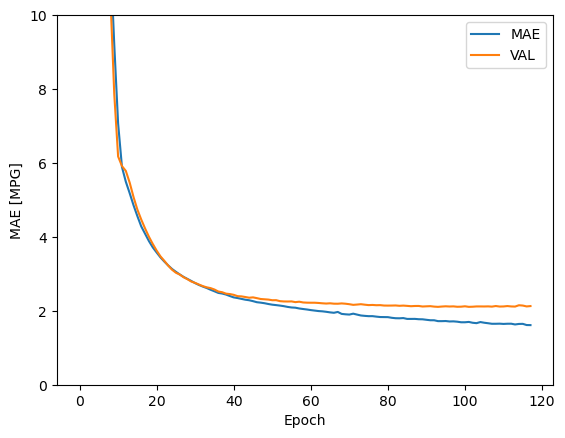

In [40]:
score = model.evaluate(X_test, y_test, verbose=1)
print("Model score:", score)

ehistory['epoch'] = early_history.epoch

plt.plot(ehistory['epoch'], ehistory['mae'], label='MAE')
plt.plot(ehistory['epoch'], ehistory['val_mae'], label='VAL')
plt.xlabel('Epoch')
plt.ylim([0, 10])
plt.ylabel('MAE [MPG]')
plt.legend()
plt.show()

In [41]:
example_result = model.predict(X_test[:10])
#print(example_result.shape)
alldata = pd.DataFrame()
alldata['expected'] = pd.Series(y_test[:10])
alldata['predict'] = example_result.reshape(-1)
print(alldata)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
     expected    predict
78       15.0  20.945517
274      22.4  20.735126
246      18.0  15.903156
55       31.0  38.654919
387      14.0  14.989489
203      20.0  18.249683
42       36.4  28.922750
233      15.0  16.590567
150      19.0  19.336184
116      35.7  33.409977


In [42]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical

In [47]:
cols = ['buying', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'class']

df = pd.read_csv("./dataset/car_evaluation.csv",names=cols)

print(df.shape)
print(df.tail)

(1728, 7)
<bound method NDFrame.tail of       buying  maint  doors  persons  lug_capacity  safety  class
0          4      4      2        2             1       1  unacc
1          4      4      2        2             1       2  unacc
2          4      4      2        2             1       3  unacc
3          4      4      2        2             2       1  unacc
4          4      4      2        2             2       2  unacc
...      ...    ...    ...      ...           ...     ...    ...
1723       1      1      5        5             2       2   good
1724       1      1      5        5             2       3  vgood
1725       1      1      5        5             3       1  unacc
1726       1      1      5        5             3       2   good
1727       1      1      5        5             3       3  vgood

[1728 rows x 7 columns]>


In [49]:
X = df[['buying', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']]

In [51]:

labels = pd.get_dummies(df['class'])

Y = labels.values

In [53]:
print(X.shape)
print(Y.shape)

(1728, 6)
(1728, 4)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [57]:
from tensorflow.keras.layers import Dense

cmodel = Sequential(name='sequential_1')

cmodel.add(Dense(15, activation='relu', input_shape=(6,), name='dense_3'))

cmodel.add(Dense(10, activation='relu', name='dense_4'))

cmodel.add(Dense(Y.shape[1], activation='softmax', name='dense_5'))

print(cmodel.summary())

C:\Users\darre\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 15)                  │             105 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │              44 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309 (1.21 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

None


In [59]:
optimizer = tf.keras.optimizers.Adam()

cmodel.compile(loss= 'mse', optimizer= optimizer, metrics=['accuracy'])

In [61]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

chistory = cmodel.fit(X_train, y_train, batch_size=8, 
                      epochs=2000,validation_split = 0.2, verbose=0, callbacks=[early_stop])


In [62]:
score = cmodel.evaluate(X_test, y_test, verbose=1)

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8799 - loss: 0.0399
Test Score: 0.033729199320077896
Test Accuracy: 0.8988439440727234


In [65]:
## Predict the model

cpredict = cmodel.predict(X_test)

#print(cpredict[:10])

labels = ['unacc', 'ac', 'good', 'vgood']

#Display first 10 data of the predicted and original column using argmax function

for i,y in zip(y_test[:10], cpredict[:10]):
    #print(i)
    invertedy = i.argmax()
    
    invertedp = y.argmax()
    
    print(labels[invertedy], labels[invertedp])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
good good
unacc unacc
good good
unacc unacc
good good
unacc good
good good
good good
good good
good good


In [67]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical

In [69]:
## Load the dataset and set input features in X


df = pd.read_csv("./dataset/diabetes.csv")

X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction', 'Age']]

print(X.head)

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1      

In [71]:
scaler = preprocessing.MinMaxScaler()

X = scaler.fit_transform(X)


In [77]:
## Prepare the target encoded data

# encode class values as integers

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoder.fit_transform(y)

encoded_Y = y

y = df['Output']

#print(y)
print(X.shape)
print(encoded_Y.shape)

(768, 8)
(768,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, encoded_Y, test_size=0.2, random_state=42)

In [81]:

bcmodel =  Sequential(name='sequential_2')

bcmodel.add(Dense(60, activation='relu', input_shape=(8,), name='dense_6'))

bcmodel.add(Dense(1, activation='relu', name='dense_7'))

print(bcmodel.summary())

C:\Users\darre\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 60)                  │             540 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              61 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 601 (2.35 KB)

 Trainable params: 601 (2.35 KB)

 Non-trainable params: 0 (0.00 B)

None


In [100]:
bcmodel.compile(loss= 'binary_crossentropy', optimizer= tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [102]:
bchistory = bcmodel.fit(X_train, y_train, batch_size=8, epochs=700, verbose=0)

score = bcmodel.evaluate(X_test, y_test, verbose=1)

print("Test Score:", score[0])

print("Test Accuracy:", score[1])

ehistory = pd.DataFrame(bchistory.history)
 
print(ehistory.tail())

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6570 - loss: 5.5286
Test Score: 5.756462574005127
Test Accuracy: 0.6428571343421936
     accuracy      loss
695  0.653094  5.591455
696  0.653094  5.591454
697  0.653094  5.591455
698  0.653094  5.591454
699  0.653094  5.591456


In [178]:
poutput = numpy_sigmoid(X)

poutput[poutput <= 0.5] = 0.
poutput[poutput > 0.5] = 1.

# Display original and predicted values
print("Original")
print(y_test[:10].to_numpy().astype(int))  
print("Predict")
print(poutput[:1].flatten())


Original
[0 0 0 0 0 0 0 0 0 0]
Predict
[1. 1. 1. 1. 0. 1. 1. 1.]


In [198]:
pdata = np.array([
    [0, 196, 66, 23, 140, 38.1, 0.6, 57],
    [5, 196, 88, 41, 150, 39.3, 0.604, 57],
    [0, 100, 66, 23, 94, 28.1, 0.23, 25]
])

#Scale the test data using MinMaxScaler

scaler = preprocessing.MinMaxScaler()

pdata = scaler.fit_transform(pdata)

poutput1 = numpy_sigmoid(pdata)


poutput1[poutput1 <= 0.5] = 0.
poutput1[poutput1 > 0.5] = 1.

print(poutput1[:, [0]])

[[0.]
 [1.]
 [0.]]
